# S14 – Качество извлечения, параметры поиска и обновление базы знаний

Во втором блокноте семинара мы переходим от базового similarity search к более инженерному вопросу: **как понять, что retrieval работает хорошо**, как на него влияют параметры чанкинга и что происходит после изменения базы знаний.

Ноутбук самодостаточный: мы заново соберём компактный retrieval-конвейер, проведём небольшой benchmark и посмотрим, как меняется качество после обновления корпуса документов.

## 0. План

К концу ноутбука вы сможете:

- собрать компактный retrieval-конвейер для учебной базы знаний;
- проверить качество извлечения на наборе контрольных запросов;
- посчитать простые retrieval-метрики: `hit@k`, `recall@k`, `MRR@k`;
- сравнить несколько конфигураций чанкинга;
- проанализировать влияние `top_k` на результаты;
- обновить базу знаний новыми документами и переиндексировать её;
- сравнить поведение retriever до и после обновления.

## 1. Импорты и общие настройки

In [1]:

# Базовые библиотеки для воспроизводимости, работы с данными и удобного вывода результатов.
import os
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def ensure_package(package_name: str, import_name: Optional[str] = None) -> None:
    """Пытается импортировать пакет и при необходимости установить его через pip."""
    target = import_name or package_name
    try:
        __import__(target)
    except Exception:
        print(f"Устанавливаем пакет: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


# Для retrieval-контура попробуем установить основные зависимости.
# Даже если sentence-transformers не поднимется, ноутбук сможет работать через fallback.
ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers", "sentence_transformers")


try:
    import faiss  # type: ignore
    FAISS_AVAILABLE = True
except Exception as e:
    FAISS_AVAILABLE = False
    print("Не удалось импортировать faiss:", repr(e))


Устанавливаем пакет: faiss-cpu


In [2]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(42)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)
print("FAISS доступен:", FAISS_AVAILABLE)

Устройство для работы: cpu
FAISS доступен: True



## 2. Корпус документов и контрольные запросы

Для оценки retrieval нужны два компонента: **корпус документов** и **benchmark-запросы** с известными релевантными ответами.  
В реальных задачах benchmark составляют вручную или получают из логов. Здесь используем учебный корпус из 8 документов и 6 контрольных вопросов, у каждого из которых заранее отмечен правильный документ-источник.


In [3]:
# Учебная база знаний по теме retrieval и RAG.
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Эмбеддинги текстов",
        "text": (
            "Эмбеддинг – это плотное векторное представление текста, в котором семантически похожие фразы "
            "располагаются близко друг к другу. Для задач retrieval эмбеддинги позволяют искать похожие "
            "документы не по точному совпадению слов, а по смыслу запроса. После нормализации векторов "
            "косинусное сходство можно считать через скалярное произведение."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "FAISS и быстрый поиск",
        "text": (
            "FAISS – библиотека для эффективного поиска ближайших соседей по векторам. "
            "В учебных примерах часто начинают с точного индекса IndexFlatIP. "
            "Если эмбеддинги нормализованы, такой индекс подходит для поиска по косинусному сходству."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Чанкинг документов",
        "text": (
            "Перед индексацией длинные документы режут на чанки – небольшие фрагменты текста. "
            "Слишком крупные чанки содержат много лишнего контекста, а слишком мелкие могут терять смысл. "
            "Overlap помогает не разрывать важную мысль на границе соседних фрагментов."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "RAG как связка retrieval и generation",
        "text": (
            "RAG объединяет два шага: сначала система извлекает релевантные фрагменты из базы знаний, "
            "а затем использует найденный контекст для генерации ответа. "
            "Если retrieval не нашёл нужный факт, генератор не сможет надёжно опереться на знания."
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Оценка качества retrieval",
        "text": (
            "Для retrieval полезно измерять hit@k, recall@k и позицию первого релевантного ответа. "
            "Даже если правильный документ есть в top-5, важно понимать, на каком месте он найден. "
            "Качество retrieval нужно проверять на наборе реальных запросов, а не только на единичных удачных примерах."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Обновление базы знаний",
        "text": (
            "Если в базе знаний появились новые документы, retriever нужно переиндексировать. "
            "После обновления корпуса важно повторно проверить качество извлечения, чтобы убедиться, "
            "что новые данные действительно доступны по запросам и не ухудшают старые сценарии."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Проблемы retrieval",
        "text": (
            "Retrieval может ошибаться по разным причинам: плохой чанкинг, слишком общий запрос, "
            "шумные документы и неудачная embedding-модель. Формальное текстовое сходство не всегда означает "
            "истинную полезность найденного фрагмента для ответа."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "Практика построения benchmark",
        "text": (
            "Небольшой benchmark для retrieval можно собрать вручную: составить список запросов "
            "и отметить документы, которые считаются релевантными. Такой benchmark не идеален, "
            "но позволяет сравнивать настройки retriever между собой и видеть динамику качества."
        ),
    },
]

documents_df = pd.DataFrame(documents)
display(documents_df[["doc_id", "title"]])

# Набор контрольных запросов и ожидаемых релевантных документов.
benchmark_queries: List[Dict[str, object]] = [
    {
        "query_id": "q01",
        "query": "Что такое эмбеддинг и зачем он нужен в retrieval?",
        "relevant_doc_ids": ["doc_01"],
    },
    {
        "query_id": "q02",
        "query": "Зачем нужен overlap при чанкинге?",
        "relevant_doc_ids": ["doc_03"],
    },
    {
        "query_id": "q03",
        "query": "Какая библиотека подходит для поиска ближайших соседей по векторам?",
        "relevant_doc_ids": ["doc_02"],
    },
    {
        "query_id": "q04",
        "query": "Какие метрики полезны для оценки retrieval?",
        "relevant_doc_ids": ["doc_05"],
    },
    {
        "query_id": "q05",
        "query": "Почему после добавления новых документов нужна переиндексация?",
        "relevant_doc_ids": ["doc_06"],
    },
    {
        "query_id": "q06",
        "query": "Почему сходство текста не всегда означает реальную полезность контекста?",
        "relevant_doc_ids": ["doc_07"],
    },
]

benchmark_df = pd.DataFrame(benchmark_queries)
display(benchmark_df)

,doc_id,title
0,doc_01,Эмбеддинги текстов
1,doc_02,FAISS и быстрый поиск
2,doc_03,Чанкинг документов
3,doc_04,RAG как связка retrieval и generation
4,doc_05,Оценка качества retrieval
5,doc_06,Обновление базы знаний
6,doc_07,Проблемы retrieval
7,doc_08,Практика построения benchmark


,query_id,query,relevant_doc_ids
0,q01,Что такое эмбеддинг и зачем он нужен в retrieval?,[doc_01]
1,q02,Зачем нужен overlap при чанкинге?,[doc_03]
2,q03,Какая библиотека подходит для поиска ближайших...,[doc_02]
3,q04,Какие метрики полезны для оценки retrieval?,[doc_05]
4,q05,Почему после добавления новых документов нужна...,[doc_06]
5,q06,Почему сходство текста не всегда означает реал...,[doc_07]



## 3. Компактный retrieval-конвейер

Ниже собираем полный, самодостаточный конвейер: чанкинг → векторизация → индекс → поиск → оценка.  
Все компоненты завёрнуты в функции и класс `RetrievalArtifacts`, чтобы можно было быстро пересобрать retriever с другими параметрами – это потребуется в секциях про чанкинг и обновление базы.  
Обратите внимание: `build_retriever` в этом ноутбуке требует наличия FAISS. Без него будет выброшен `RuntimeError`.


In [4]:
# В этом разделе собираем self-contained реализацию:
# чанкинг -> векторизация -> индекс -> поиск -> оценка.

def chunk_text(text: str, chunk_size: int = 40, overlap: int = 10) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на fallback.")
        print("Причина:", repr(e))
        return TfidfBackend()


def build_chunks(
    docs: List[Dict[str, str]],
    chunk_size: int,
    overlap: int,
) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for doc in docs:
        parts = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk_text_value in enumerate(parts):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx}",
                    "chunk_idx": chunk_idx,
                    "chunk_text": chunk_text_value,
                }
            )
    return rows


@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 40,
    overlap: int = 10,
    device: str = "cpu",
) -> RetrievalArtifacts:
    chunks = build_chunks(docs, chunk_size=chunk_size, overlap=overlap)
    chunks_df = pd.DataFrame(chunks)

    backend = select_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    if not FAISS_AVAILABLE:
        raise RuntimeError("FAISS недоступен. Для этого ноутбука ожидается установленный faiss-cpu.")

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )


def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)


def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)


## 4. Базовый retrieval и контрольные примеры

Строим первую версию retriever с конкретными параметрами чанкинга (`chunk_size=28`, `overlap=8`).  
Это **baseline** – точка отсчёта для всех дальнейших сравнений. Сначала прогоняем несколько запросов вручную, чтобы убедиться, что retrieval вообще работает осмысленно, прежде чем считать метрики.


In [5]:
# Собираем baseline-конфигурацию retriever.
baseline_chunk_size = 28
baseline_overlap = 8

artifacts = build_retriever(
    documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

# Посмотрим несколько контрольных запросов вручную.
sample_queries = [
    "Что такое эмбеддинги?",
    "Как оценивать retrieval?",
    "Зачем переиндексировать базу знаний после обновления?",
]

for query in sample_queries:
    display(Markdown(f"### Запрос: {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

,rank,score,doc_id,title,chunk_text
0,1,0.532740,doc_01,Эмбеддинги текстов,Эмбеддинг – это плотное векторное представлени...
1,2,0.289396,doc_08,Практика построения benchmark,но позволяет сравнивать настройки retriever ме...
2,3,0.237379,doc_02,FAISS и быстрый поиск,FAISS – библиотека для эффективного поиска бли...


### Запрос: Как оценивать retrieval?

,rank,score,doc_id,title,chunk_text
0,1,0.722318,doc_05,Оценка качества retrieval,"Для retrieval полезно измерять hit@k, recall@k..."
1,2,0.705103,doc_05,Оценка качества retrieval,на каком месте он найден. Качество retrieval н...
2,3,0.695151,doc_08,Практика построения benchmark,Небольшой benchmark для retrieval можно собрат...


### Запрос: Зачем переиндексировать базу знаний после обновления?

,rank,score,doc_id,title,chunk_text
0,1,0.654466,doc_06,Обновление базы знаний,"Если в базе знаний появились новые документы, ..."
1,2,0.413983,doc_04,RAG как связка retrieval и generation,RAG объединяет два шага: сначала система извле...
2,3,0.406293,doc_04,RAG как связка retrieval и generation,"Если retrieval не нашёл нужный факт, генератор..."



## 5. Простая оценка качества извлечения

Прогоняем весь benchmark и считаем три метрики:

- **hit@k** – нашёлся ли хотя бы один релевантный документ в top-k (0 или 1);
- **recall@k** – доля найденных релевантных документов из всех ожидаемых;
- **MRR@k** (Mean Reciprocal Rank) – обратный ранг первого релевантного документа. Чем ближе к 1, тем выше позиция нужного фрагмента.

Для запросов с одним релевантным документом recall и hit совпадают. MRR информативен именно здесь: он показывает, на каком месте обычно оказывается нужный ответ.


In [6]:
# Прогоняем весь benchmark и считаем метрики для baseline-конфигурации.
baseline_eval_k3 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "value": [
            baseline_eval_k3["hit@3"].mean(),
            baseline_eval_k3["recall@3"].mean(),
            baseline_eval_k3["MRR@3"].mean(),
        ],
    }
)
display(summary_k3)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Что такое эмбеддинг и зачем он нужен в retrieval?,doc_01,"doc_01, doc_07, doc_05",1,1.0,1.0,1
1,q02,Зачем нужен overlap при чанкинге?,doc_03,"doc_03, doc_07",1,1.0,1.0,1
2,q03,Какая библиотека подходит для поиска ближайших...,doc_02,"doc_02, doc_01, doc_08",1,1.0,1.0,1
3,q04,Какие метрики полезны для оценки retrieval?,doc_05,"doc_08, doc_05",1,1.0,0.5,2
4,q05,Почему после добавления новых документов нужна...,doc_06,"doc_06, doc_03, doc_07",1,1.0,1.0,1
5,q06,Почему сходство текста не всегда означает реал...,doc_07,"doc_07, doc_03",1,1.0,1.0,1


,metric,value
0,mean_hit@3,1.000000
1,mean_recall@3,1.000000
2,mean_MRR@3,0.916667


Здесь важно смотреть не только на факт попадания релевантного документа в `top_k`, но и на его позицию.  
Если правильный документ стабильно находится на 3-м месте, это уже лучше, чем полное отсутствие попаданий, но всё ещё может быть проблемой для реального RAG-контура.


## 6. Как влияют `chunk_size` и `overlap`

Пересобираем retriever с четырьмя разными настройками чанкинга и сравниваем метрики.  
На небольшом учебном корпусе разрыв между конфигурациями может быть небольшим: документы короткие, а контекст в каждом чанке хорошо сохраняется. На реальных, более длинных текстах разница обычно заметнее.  
Таблица сортируется по качеству (лучший вариант → первая строка), а график строится по возрастанию `chunk_size` для удобства чтения.


In [7]:
# Сравниваем несколько конфигураций чанкинга.
chunk_configs = [
    {"chunk_size": 18, "overlap": 4},
    {"chunk_size": 28, "overlap": 8},
    {"chunk_size": 40, "overlap": 10},
    {"chunk_size": 60, "overlap": 15},
]

chunk_experiments = []

for cfg in chunk_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg["chunk_size"],
        overlap=cfg["overlap"],
        device=DEVICE,
    )
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=exp_artifacts, top_k=3)

    chunk_experiments.append(
        {
            "chunk_size": cfg["chunk_size"],
            "overlap": cfg["overlap"],
            "num_chunks": len(exp_artifacts.chunks_df),
            "backend_name": exp_artifacts.backend_name,
            "mean_hit@3": eval_df["hit@3"].mean(),
            "mean_recall@3": eval_df["recall@3"].mean(),
            "mean_MRR@3": eval_df["MRR@3"].mean(),
        }
    )

chunk_experiments_df = pd.DataFrame(chunk_experiments).sort_values(
    by=["mean_hit@3", "mean_MRR@3", "num_chunks"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(chunk_experiments_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Используем dense-модель эмбеддингов.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,chunk_size,overlap,num_chunks,backend_name,mean_hit@3,mean_recall@3,mean_MRR@3
0,60,15,8,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.916667
1,40,10,9,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.916667
2,28,8,15,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.916667
3,18,4,20,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.833333


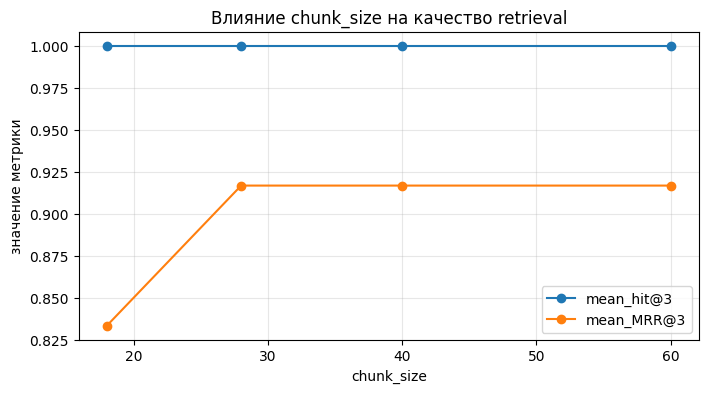

In [8]:

# Небольшая визуализация: как меняется качество при разных конфигурациях чанкинга.
# chunk_experiments_df отсортирован по качеству; для графика обязательно сортируем по chunk_size,
# иначе ось X будет в произвольном порядке и линии пересекутся.
plot_df = chunk_experiments_df.sort_values("chunk_size").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["chunk_size"], plot_df["mean_hit@3"], marker="o", label="mean_hit@3")
plt.plot(plot_df["chunk_size"], plot_df["mean_MRR@3"], marker="o", label="mean_MRR@3")
plt.xlabel("chunk_size")
plt.ylabel("значение метрики")
plt.title("Влияние chunk_size на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



На практике нет универсально лучшего размера чанка.  
Слишком маленькие чанки дают больше фрагментов и увеличивают шанс вытащить кусок с нужной формулировкой, но могут терять смысл.  
Слишком большие чанки лучше сохраняют контекст, но растут шум и вычислительные затраты.

**Почему здесь `mean_hit@3` почти везде 1.0 и разброс по `MRR` небольшой?**  
Наш учебный корпус очень маленький (8 коротких документов, каждый посвящён одной теме).  
Sentence-transformers хорошо справляется с такими запросами независимо от способа чанкинга.  
На реальных корпусах – с длинными текстами, смешанными темами и тысячами чанков – разрыв между конфигурациями обычно заметно больше.



## 7. Как влияет `top_k`

Фиксируем baseline-конфигурацию чанкинга и варьируем количество возвращаемых фрагментов.  
`hit@k` растёт или остаётся при увеличении `k`, `MRR@k` при этом стабилизируется: если нужный документ уже на первом месте, увеличение `k` на него не влияет.  
Цель этого эксперимента – понять, при каком `top_k` retriever стабильно находит нужный фрагмент, не добавляя лишнего шума в контекст.


,top_k,mean_hit,mean_recall,mean_MRR
0,1,0.833333,0.833333,0.833333
1,2,1.000000,1.000000,0.916667
2,3,1.000000,1.000000,0.916667
3,4,1.000000,1.000000,0.916667
4,5,1.000000,1.000000,0.916667


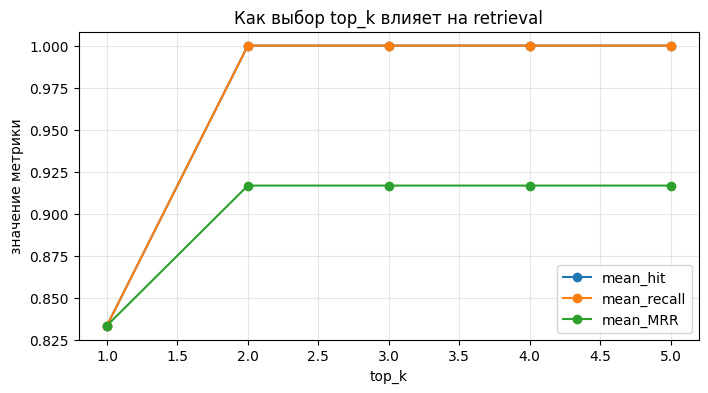

In [9]:
# Фиксируем baseline-конфигурацию и смотрим, как меняются метрики при разных top_k.
topk_rows = []

for top_k in [1, 2, 3, 4, 5]:
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=top_k)
    topk_rows.append(
        {
            "top_k": top_k,
            "mean_hit": eval_df[f"hit@{top_k}"].mean(),
            "mean_recall": eval_df[f"recall@{top_k}"].mean(),
            "mean_MRR": eval_df[f"MRR@{top_k}"].mean(),
        }
    )

topk_df = pd.DataFrame(topk_rows)
display(topk_df)

plt.figure(figsize=(8, 4))
plt.plot(topk_df["top_k"], topk_df["mean_hit"], marker="o", label="mean_hit")
plt.plot(topk_df["top_k"], topk_df["mean_recall"], marker="o", label="mean_recall")
plt.plot(topk_df["top_k"], topk_df["mean_MRR"], marker="o", label="mean_MRR")
plt.xlabel("top_k")
plt.ylabel("значение метрики")
plt.title("Как выбор top_k влияет на retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Рост `top_k` почти всегда повышает шанс увидеть релевантный документ в выдаче, но это не означает автоматического улучшения RAG.  
Слишком большой `top_k` может добавить в контекст лишние фрагменты и запутать генератор.


## 8. Обновляем базу знаний

Представим реалистичный сценарий: в корпус добавили два новых документа – о реранжировании и о гибридном поиске.  
Сначала проверяем, как **baseline-retriever** (без новых документов) отвечает на запросы о них – ожидаемо плохо.  
Затем переиндексируем корпус целиком и сравниваем результаты до и после.


In [10]:
# Представим, что база знаний пополнилась новыми документами.
new_documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_09",
        "title": "Реранжирование результатов retrieval",
        "text": (
            "После первичного поиска можно применить реранжирование: сначала retriever достаёт несколько "
            "кандидатов, а затем более точная модель пересортировывает их по полезности. "
            "Это особенно полезно, когда базовый retrieval находит тематически близкие, но не самые точные фрагменты."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Гибридный поиск",
        "text": (
            "Гибридный поиск объединяет dense retrieval и классический лексический поиск. "
            "Он помогает в случаях, когда часть запросов требует смыслового соответствия, "
            "а часть – точного совпадения терминов, названий или аббревиатур."
        ),
    },
]

updated_documents = documents + new_documents

display(pd.DataFrame(new_documents)[["doc_id", "title"]])

new_queries = [
    "Зачем нужен реранжировщик после первичного retrieval?",
    "Когда полезен гибридный поиск?",
]

display(Markdown("### Как baseline-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

,doc_id,title
0,doc_09,Реранжирование результатов retrieval
1,doc_10,Гибридный поиск


### Как baseline-база отвечает на новые запросы

**Запрос:** Зачем нужен реранжировщик после первичного retrieval?

,rank,score,doc_id,title,chunk_text
0,1,0.591524,doc_07,Проблемы retrieval,Retrieval может ошибаться по разным причинам: ...
1,2,0.589424,doc_06,Обновление базы знаний,"Если в базе знаний появились новые документы, ..."
2,3,0.583493,doc_05,Оценка качества retrieval,на каком месте он найден. Качество retrieval н...


**Запрос:** Когда полезен гибридный поиск?

,rank,score,doc_id,title,chunk_text
0,1,0.442429,doc_05,Оценка качества retrieval,на каком месте он найден. Качество retrieval н...
1,2,0.428342,doc_08,Практика построения benchmark,но позволяет сравнивать настройки retriever ме...
2,3,0.402839,doc_02,FAISS и быстрый поиск,FAISS – библиотека для эффективного поиска бли...



## 9. Переиндексация и сравнение до/после обновления

Строим `updated_artifacts` на расширенном корпусе (10 документов) и прогоняем **расширенный benchmark** (8 запросов, включая два новых – про реранжирование и гибридный поиск) через обе версии retriever.  
`before_update_eval` для q07 и q08 должен показывать `hit@3 = 0` – эти документы ещё не были в индексе.  
`after_update_eval` должен исправить эти пропуски. В итоговом `summary_comparison_df` колонка `delta` покажет прирост качества.


In [11]:
# Переиндексируем корпус уже с новыми документами.
updated_artifacts = build_retriever(
    updated_documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

# Расширяем benchmark новыми запросами.
extended_benchmark_queries = benchmark_queries + [
    {
        "query_id": "q07",
        "query": "Зачем нужен реранжировщик после первичного retrieval?",
        "relevant_doc_ids": ["doc_09"],
    },
    {
        "query_id": "q08",
        "query": "Когда полезен гибридный поиск?",
        "relevant_doc_ids": ["doc_10"],
    },
]

before_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=updated_artifacts, top_k=3)

comparison_df = before_update_eval.merge(
    after_update_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)

display(comparison_df)

summary_comparison_df = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "before_update": [
            before_update_eval["hit@3"].mean(),
            before_update_eval["recall@3"].mean(),
            before_update_eval["MRR@3"].mean(),
        ],
        "after_update": [
            after_update_eval["hit@3"].mean(),
            after_update_eval["recall@3"].mean(),
            after_update_eval["MRR@3"].mean(),
        ],
    }
)
summary_comparison_df["delta"] = summary_comparison_df["after_update"] - summary_comparison_df["before_update"]
display(summary_comparison_df)

display(Markdown("### Как updated-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=updated_artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,query_id,query,relevant_doc_ids,predicted_doc_ids_before,hit@3_before,recall@3_before,MRR@3_before,first_relevant_rank_before,predicted_doc_ids_after,hit@3_after,recall@3_after,MRR@3_after,first_relevant_rank_after
0,q01,Что такое эмбеддинг и зачем он нужен в retrieval?,doc_01,"doc_01, doc_07, doc_05",1,1.0,1.0,1.0,"doc_01, doc_09",1,1.0,1.0,1
1,q02,Зачем нужен overlap при чанкинге?,doc_03,"doc_03, doc_07",1,1.0,1.0,1.0,"doc_03, doc_10",1,1.0,1.0,1
2,q03,Какая библиотека подходит для поиска ближайших...,doc_02,"doc_02, doc_01, doc_08",1,1.0,1.0,1.0,"doc_02, doc_09, doc_01",1,1.0,1.0,1
3,q04,Какие метрики полезны для оценки retrieval?,doc_05,"doc_08, doc_05",1,1.0,0.5,2.0,"doc_08, doc_05, doc_09",1,1.0,0.5,2
4,q05,Почему после добавления новых документов нужна...,doc_06,"doc_06, doc_03, doc_07",1,1.0,1.0,1.0,"doc_06, doc_03, doc_07",1,1.0,1.0,1
5,q06,Почему сходство текста не всегда означает реал...,doc_07,"doc_07, doc_03",1,1.0,1.0,1.0,"doc_07, doc_03",1,1.0,1.0,1
6,q07,Зачем нужен реранжировщик после первичного ret...,doc_09,"doc_07, doc_06, doc_05",0,0.0,0.0,NaN,"doc_09, doc_07",1,1.0,1.0,1
7,q08,Когда полезен гибридный поиск?,doc_10,"doc_05, doc_08, doc_02",0,0.0,0.0,NaN,"doc_10, doc_09, doc_05",1,1.0,1.0,1


,metric,before_update,after_update,delta
0,mean_hit@3,0.7500,1.0000,0.25
1,mean_recall@3,0.7500,1.0000,0.25
2,mean_MRR@3,0.6875,0.9375,0.25


### Как updated-база отвечает на новые запросы

**Запрос:** Зачем нужен реранжировщик после первичного retrieval?

,rank,score,doc_id,title,chunk_text
0,1,0.661294,doc_09,Реранжирование результатов retrieval,После первичного поиска можно применить реранж...
1,2,0.635392,doc_09,Реранжирование результатов retrieval,"Это особенно полезно, когда базовый retrieval ..."
2,3,0.591524,doc_07,Проблемы retrieval,Retrieval может ошибаться по разным причинам: ...


**Запрос:** Когда полезен гибридный поиск?

,rank,score,doc_id,title,chunk_text
0,1,0.674102,doc_10,Гибридный поиск,Гибридный поиск объединяет dense retrieval и к...
1,2,0.593860,doc_09,Реранжирование результатов retrieval,После первичного поиска можно применить реранж...
2,3,0.442429,doc_05,Оценка качества retrieval,на каком месте он найден. Качество retrieval н...



## 10. Разбор неудачных кейсов

Смотрим, по каким запросам retriever всё ещё ошибается или возвращает нужный документ не на первом месте (`first_relevant_rank > 1`).  
На нашем маленьком учебном корпусе неудачных случаев может не оказаться совсем – это нормально. В реальных задачах таких случаев всегда хватает, и их ручной разбор часто информативнее самих метрик.


In [12]:
# Посмотрим, по каким запросам retrieval всё ещё может ошибаться.
analysis_rows = []

for row in extended_benchmark_queries:
    metrics = evaluate_query(
        query=row["query"],
        relevant_doc_ids=row["relevant_doc_ids"],
        artifacts=updated_artifacts,
        top_k=3,
    )
    analysis_rows.append(
        {
            "query_id": row["query_id"],
            "query": row["query"],
            "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
            "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
            "hit@3": metrics["hit"],
            "first_relevant_rank": metrics["first_relevant_rank"],
        }
    )

analysis_df = pd.DataFrame(analysis_rows)
failed_or_weak = analysis_df[
    (analysis_df["hit@3"] == 0) | (analysis_df["first_relevant_rank"].fillna(99) > 1)
].reset_index(drop=True)

display(failed_or_weak if len(failed_or_weak) > 0 else analysis_df.head(0))

if len(failed_or_weak) == 0:
    print("На этом маленьком benchmark все запросы нашли релевантный документ на первом месте.")
else:
    print("Запросы выше стоит разобрать вручную: возможно, проблема в формулировке запроса, чанкинге или составе корпуса.")

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,first_relevant_rank
0,q04,Какие метрики полезны для оценки retrieval?,doc_05,"doc_08, doc_05, doc_09",1,2


Запросы выше стоит разобрать вручную: возможно, проблема в формулировке запроса, чанкинге или составе корпуса.


Даже если benchmark маленький и выглядит «хорошо», это не повод считать retriever готовым к production.  
Обычно после такого этапа переходят к более реалистичному набору запросов, ручному анализу ошибок и сравнению нескольких embedding-моделей.

## 11. Ограничения текущего подхода

В этом ноутбуке мы упростили реальный retrieval-контур:

- используем маленький учебный корпус, а не большой набор документов;
- считаем релевантность на уровне документов, а не отдельных чанков;
- не вводим отдельный этап реранжирования;
- не оцениваем latency, стоимость и объём индекса;
- не подключаем генеративную модель, а анализируем только retrieval.

Но именно такой упрощённый benchmark уже позволяет сравнивать настройки **не на уровне ощущений, а на уровне чисел**.

## 12. Итоги

В этом ноутбуке мы:

- собрали компактный retrieval-конвейер;
- сформировали набор контрольных запросов;
- посчитали `hit@k`, `recall@k`, `MRR@k`;
- сравнили несколько вариантов чанкинга;
- посмотрели, как выбор `top_k` влияет на выдачу;
- обновили базу знаний и переиндексировали индекс;
- сравнили качество до и после обновления корпуса.

Это и есть минимальная инженерная основа для следующего шага – **mini-RAG**, где retrieval становится источником контекста для генерации ответа.

## Задания для самостоятельной работы

1. Добавьте в корпус 3-5 новых документов и проверьте, меняются ли метрики retrieval.
2. Расширьте benchmark новыми запросами, включая неоднозначные и пограничные формулировки.
3. Сравните минимум две разные embedding-модели, если у вас есть доступ к интернету и GPU.
4. Попробуйте ввести отдельный этап реранжирования top-5 результатов.
5. Подумайте, какие запросы особенно опасны для RAG, если retrieval ошибается.